<a href="https://colab.research.google.com/github/Raksh1707/Naturalproject/blob/main/nlp9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import string
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

# Download required NLTK data
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [4]:
feedback = [

    "The faculty explains concepts very clearly.",
    "The classroom needs better ventilation.",
    "The practical sessions are very useful.",
    "Too many assignments every week.",
    "The teaching method is excellent.",
    "The laboratory equipment needs improvement.",
    "Notes provided by the teacher are helpful.",
    "Internet connectivity in the lab is poor.",
    "The syllabus is well organized.",
    "The classroom projector is not working properly.",
    "Faculty members are very supportive.",
    "More industry workshops should be conducted.",
    "The library has a good collection of books.",
    "The canteen food quality should improve.",
    "The examination schedule is stressful.",
    "The placement training sessions are excellent.",
    "The classroom is always clean.",
    "The WiFi speed is very slow.",
    "The teaching pace is too fast.",
    "The faculty encourages student participation.",
    "The computer systems need upgrading.",
    "The course content is informative.",
    "More hands-on practical sessions are required.",
    "The staff are friendly and cooperative.",
    "The college campus is well maintained.",
    "The attendance system is convenient.",
    "The washrooms need better maintenance.",
    "The online learning portal is easy to use.",
    "The timetable should be planned better.",
    "Overall I am satisfied with my learning experience."

]

df = pd.DataFrame({
    "Feedback": feedback
})

print("First Five Feedback Records")
print(df.head())


First Five Feedback Records
                                      Feedback
0  The faculty explains concepts very clearly.
1      The classroom needs better ventilation.
2      The practical sessions are very useful.
3             Too many assignments every week.
4            The teaching method is excellent.


In [5]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Clean_Feedback"] = df["Feedback"].apply(clean_text)

print("\nCleaned Feedback")
print(df[["Feedback","Clean_Feedback"]].head())



Cleaned Feedback
                                      Feedback  \
0  The faculty explains concepts very clearly.   
1      The classroom needs better ventilation.   
2      The practical sessions are very useful.   
3             Too many assignments every week.   
4            The teaching method is excellent.   

                       Clean_Feedback  
0   faculty explains concepts clearly  
1  classroom needs better ventilation  
2           practical sessions useful  
3         many assignments every week  
4           teaching method excellent  


In [6]:
sia = SentimentIntensityAnalyzer()

def sentiment(text):

    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Feedback"].apply(sentiment)

print("\nSentiment Analysis")
print(df[["Feedback","Sentiment"]])



Sentiment Analysis
                                             Feedback Sentiment
0         The faculty explains concepts very clearly.  Positive
1             The classroom needs better ventilation.  Positive
2             The practical sessions are very useful.  Positive
3                    Too many assignments every week.   Neutral
4                   The teaching method is excellent.  Positive
5         The laboratory equipment needs improvement.  Positive
6          Notes provided by the teacher are helpful.  Positive
7           Internet connectivity in the lab is poor.  Negative
8                     The syllabus is well organized.  Positive
9    The classroom projector is not working properly.   Neutral
10               Faculty members are very supportive.  Positive
11       More industry workshops should be conducted.   Neutral
12        The library has a good collection of books.  Positive
13           The canteen food quality should improve.  Positive
14             The e

In [7]:
keywords = [

    "classroom",
    "faculty",
    "teacher",
    "laboratory",
    "wifi",
    "internet",
    "library",
    "canteen",
    "assignments",
    "placement",
    "projector",
    "timetable",
    "syllabus",
    "practical",
    "attendance",
    "maintenance"

]

words = " ".join(df["Clean_Feedback"]).split()

issues = [word for word in words if word in keywords]

issue_count = Counter(issues)

print("\nCommon Student Concerns")

for word, count in issue_count.items():
    print(word, ":", count)



Common Student Concerns
faculty : 3
classroom : 3
practical : 2
assignments : 1
laboratory : 1
teacher : 1
internet : 1
syllabus : 1
projector : 1
library : 1
canteen : 1
placement : 1
wifi : 1
attendance : 1
maintenance : 1
timetable : 1


In [8]:
print("\nImprovement Suggestions")

for word, count in issue_count.most_common():

    if word == "wifi":
        print("- Improve campus WiFi speed.")

    elif word == "laboratory":
        print("- Upgrade laboratory equipment.")

    elif word == "canteen":
        print("- Improve food quality in the canteen.")

    elif word == "assignments":
        print("- Reduce assignment workload.")

    elif word == "projector":
        print("- Repair classroom projectors.")

    elif word == "classroom":
        print("- Improve classroom facilities.")

    elif word == "maintenance":
        print("- Enhance campus maintenance.")

    elif word == "placement":
        print("- Conduct more placement training.")

    elif word == "practical":
        print("- Increase practical learning sessions.")


Improvement Suggestions
- Improve classroom facilities.
- Increase practical learning sessions.
- Reduce assignment workload.
- Upgrade laboratory equipment.
- Repair classroom projectors.
- Improve food quality in the canteen.
- Conduct more placement training.
- Improve campus WiFi speed.
- Enhance campus maintenance.


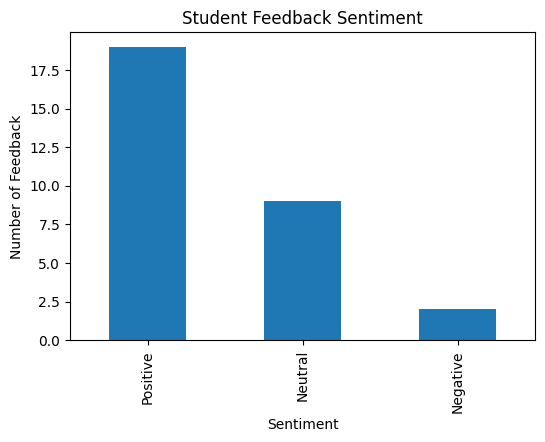

In [9]:
plt.figure(figsize=(6,4))

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Student Feedback Sentiment")

plt.xlabel("Sentiment")

plt.ylabel("Number of Feedback")

plt.show()

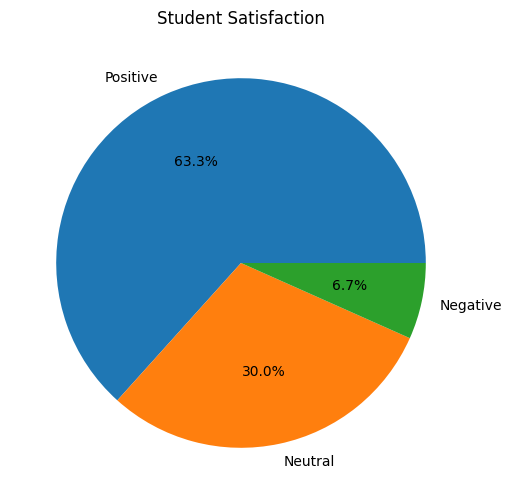

In [10]:
plt.figure(figsize=(6,6))

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Student Satisfaction")

plt.show()

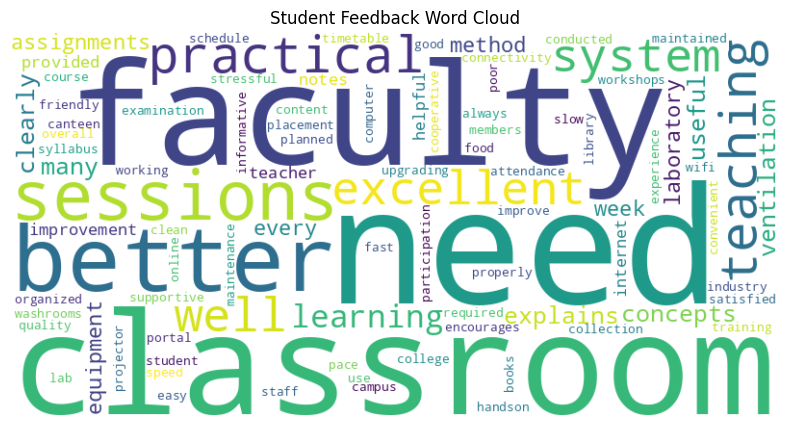

In [11]:
text = " ".join(df["Clean_Feedback"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Student Feedback Word Cloud")

plt.show()

In [12]:

df.to_csv("Student_Feedback_Analysis_Output.csv", index=False)

print("\nAnalysis Completed Successfully!")
print("Output saved as Student_Feedback_Analysis_Output.csv")


Analysis Completed Successfully!
Output saved as Student_Feedback_Analysis_Output.csv
